Section 1 – Introduction

Customer Churn Prediction

Customer churn refers to customers discontinuing their subscription to a company's services. Predicting churn allows businesses to proactively retain customers through targeted marketing and customer service efforts.

The objective of this project is to clean and prepare the Telco Customer Churn dataset for machine learning. This notebook demonstrates the complete data wrangling process including data acquisition, exploration, cleaning, and preparation.

Section 2 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

Section 3 – Load Dataset

In [3]:
df = pd.read_csv("C:\\Users\\kedha\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Section 4 – Explore the Data



Before cleaning the dataset, it is important to understand its overall structure. In this section, we examine the size of the dataset, identify the target variable, and distinguish between numerical and categorical features. This initial exploration provides insight into the data and helps guide the data wrangling process.

4.1 Dataset Dimensions

In [8]:
print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Shape: (7043, 21)

Number of Rows: 7043
Number of Columns: 21


The dataset dimensions indicate how many customer records are available for analysis and how many variables are included. Each row represents one customer, while each column represents a feature describing that customer.

4.2 Column Names

In [9]:
print("Dataset Columns:\n")
print(df.columns.tolist())

Dataset Columns:

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Reviewing the column names provides an overview of the available customer information, including demographic details, account information, services subscribed to, billing information, and the target variable used for prediction.

4.3 Identify the Target Variable

In [10]:
print("Target Variable: Churn\n")

print(df["Churn"].value_counts())

print("\nPercentage Distribution:")
print(df["Churn"].value_counts(normalize=True) * 100)

Target Variable: Churn

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


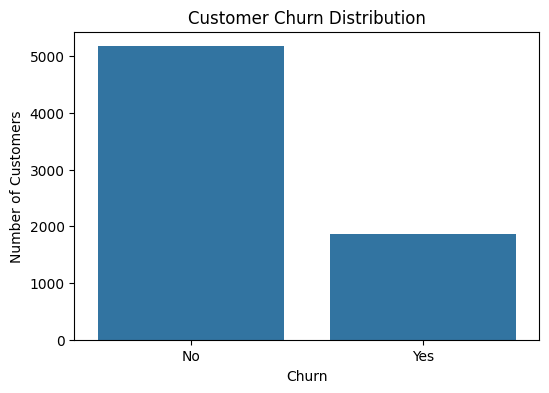

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

The **Churn** column is the target variable for this project. It indicates whether a customer has left the company's service ("Yes") or remained a customer ("No"). Understanding the class distribution is important because an imbalanced dataset may influence machine learning model performance.

4.4 Numerical Variables

In [12]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Variables:")
print(numerical_columns.tolist())

print(f"\nTotal Numerical Variables: {len(numerical_columns)}")

Numerical Variables:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Total Numerical Variables: 3


In [13]:
df[numerical_columns].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Numerical variables contain quantitative information such as customer tenure, monthly charges, total charges, and senior citizen status. Summary statistics provide insight into the range, average, and distribution of these variables.

4.5 Categorical Variables

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Variables:")
print(categorical_columns.tolist())

print(f"\nTotal Categorical Variables: {len(categorical_columns)}")

Categorical Variables:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Total Categorical Variables: 18


C:\Users\kedha\AppData\Local\Temp\ipykernel_11184\588305091.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [15]:
for column in categorical_columns:
    print(f"{column}: {df[column].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


Most variables in this dataset are categorical and represent customer characteristics or subscribed services. Examining the unique values helps identify inconsistent labels, unexpected categories, and variables that may require encoding before machine learning.

4.6 Overall Dataset Information

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen



The initial exploration reveals that the dataset contains customer demographic information, service subscriptions, account details, and billing information. The target variable, **Churn**, will be used to build a predictive machine learning model. Both numerical and categorical variables are present, requiring different preprocessing techniques during the data wrangling stage. The next step is to inspect the dataset for missing values, duplicate records, incorrect data types, and other data quality issues before model development.

Section 5 – Data Cleaning

1. Missing Values

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [19]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The TotalCharges column contains blank strings instead of actual missing values. These were converted to NaN so they can be handled appropriately.

In [20]:
df.dropna(inplace=True)

Because only a small number of observations contained missing values (<0.2% of the dataset), these rows were removed instead of imputed.

2. Duplicate Records

In [21]:
df.duplicated().sum()

np.int64(0)

No duplicate records were identified.

3. Data Types

In [22]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [23]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

4. Unique Values

In [24]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())

customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str
gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

C:\Users\kedha\AppData\Local\Temp\ipykernel_11184\619270188.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


5. Standardize Categories

In [25]:
df["MultipleLines"] = df["MultipleLines"].replace(
    {"No phone service":"No"}
)

6. Outliers

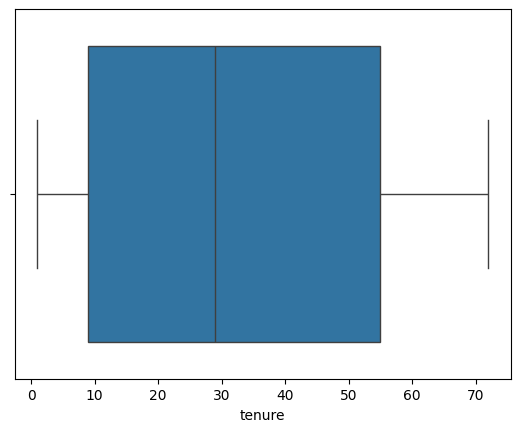

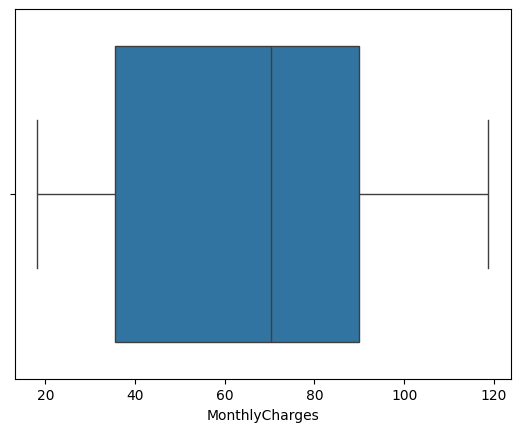

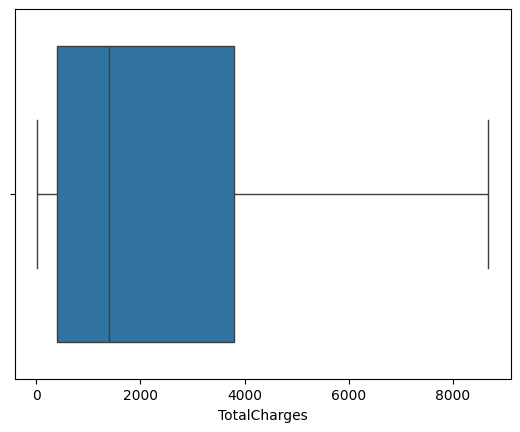

In [26]:
numeric_cols = ["tenure","MonthlyCharges","TotalCharges"]

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.show()

7. Feature Engineering

In [28]:
df["AverageMonthlySpend"] = df["TotalCharges"] / df["tenure"]

Section 6 – Save Clean Dataset

In [29]:
df.to_csv("Telco_Churn_Clean.csv", index=False)

Section 7 – Final Summary

During the data wrangling process, missing values were identified and removed, data types were corrected, duplicate records were checked, categorical variables were reviewed for consistency, and numerical variables were examined for outliers. The resulting dataset is clean and ready for exploratory analysis and predictive modeling.